# Normal and Outliers

Sometimes the most effective way to grasp the data is through summary statistics or other numerical measures. Often, however, it is a picture that tells a thousand words. Knowing how to best convey the underlying meaning in a dataset is a hugely important aspect of communicating results.

**Univariate analysis** involves observations consisting of only one variable. It is the simplest, yet most effective form of statistical analysis. Common visuals include:

1. histograms
2. box plots
3. density plots

They help us detect patterns like skewness or outliers that affect data interpretation.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Example 1 (Interactive): Standardized Test Scores

Exams like the SAT or IQ tests are specifically **designed** so that the results fall into a normal distribution, allowing scorers to see how an individual compares to the "average" ($\mu$).

iIf students in a math class took a final exam, and the class average was 7.5 out of 10 and the standard deviation was 0.5 points. If the class scores follow a normal distribution, then this means that:

- 68% of the students received a score between 7.0 and 8.0 on the test, or the mean (7.5) plus or minus 1 standard deviation (0.5)
- 95% of students received a grade between 6.5 and 8.5 on the exam, or the mean (7.5) plus or minus 2 standard deviations (1.0)
- 99.7% of students received a grade between 6.0 and 9.0, or the mean (7.5) plus or minor 3 standard deviations

**The following is an interactive example which you can try out to play with the normal distribution**:

- Changing the `mean` would move the `median`, `min` and `max` statistics with it, but won't have an effect on the `range` statistic.
- Changing the `std` would affect the `min` and `max` statistics and consequently, the `range` statstic, but won't have an effect on the `median`.

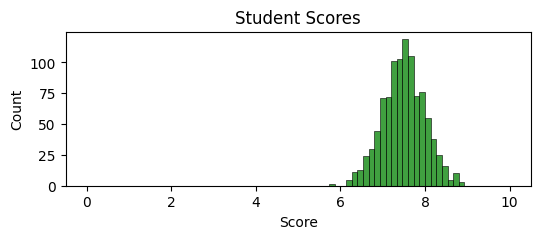

In [2]:
# Generate data
scores = np.random.normal(
    loc=7.5,   # Mean               <<----- CHANGE THIS
    scale=0.5, # Standard Deviation <<----- CHANGE THIS
    size=1000  # Number of observations
)
df = pd.DataFrame(scores, columns=['Score'])

# Plot
fig, ax = plt.subplots(figsize=(6, 2))
sns.histplot(df['Score'], binrange=(0, 10), color='green')
ax.set(title="Student Scores");

**Try and Observe**: try changing the mean and standard deviation in the above code to see how normal curve behaves.

## Example 2: Human Heights and Weights

The [Human Heights and Weights Dataset](https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset) contains 25,000 rows. (note that we added `BMI` and `classification`)

In [ ]:
# Load dataset
humans = pd.read_csv("../data/SOCR-HeightWeight_modified.csv", index_col=0)
humans

,Height(m),Weight(kg),BMI,classification
Index,,,,
1,1.670896,51.252494,18.357609,Mild Thinness
2,1.816486,61.909547,18.762615,Normal
3,1.762728,69.411778,22.338940,Normal
4,1.732702,64.562199,21.504569,Normal
5,1.721810,65.452010,22.077625,Normal
...,...,...,...,...
24996,1.765355,53.538008,17.179016,Mild Thinness
24997,1.639526,54.518674,20.281906,Normal
24998,1.643343,53.644285,19.864010,Normal


In [4]:
# Summary statistics
humans.describe()

,Height(m),Weight(kg),BMI
count,25000.000000,25000.000000,25000.000000
mean,1.727025,57.642209,19.321494
std,0.048303,5.289290,1.551898
min,1.531070,35.386871,13.070852
25%,1.694292,54.117461,18.278321
50%,1.727091,57.677738,19.302236
75%,1.759533,61.186318,20.357697
max,1.908881,77.529759,26.023703


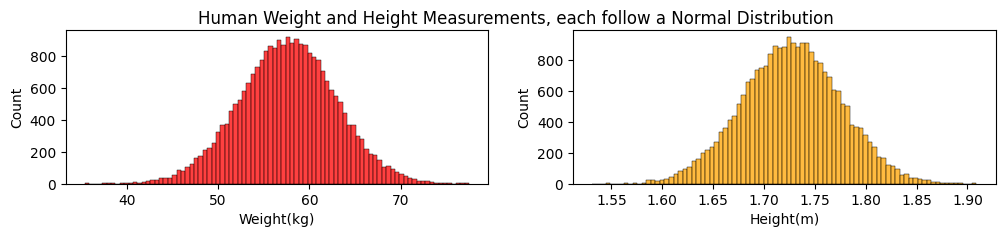

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 2))

fig.suptitle("Human Weight and Height Measurements, each follow a Normal Distribution")
sns.histplot(humans, x="Weight(kg)", color="red", ax=ax[0]);
sns.histplot(humans, x="Height(m)", color="orange", ax=ax[1]);

## Outliers: far from normal

An **Outlier** is an observation which deviates **"too much"** from other observations. Since statistical models look at the group, members that aren't likely of the same group distort these models and affect our calculated statistics, especially when the outliers are exterme and numerous.

We **don't automatically remove** these values, rather, we might want to inspect further to know more about their story.

Deciding how much is "too much" can be done many ways:

1. The **Z-Score method**
2. The **IQR method**
3. others..

### 1. Z-Score Method

The most common one that works well with the *Normal Distribution* is the **Z-score method**, which is calculated by subtracting the mean and dividing by the standard deviation:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

- $\mu$ is the mean
- $\sigma$ is the standard deviation

The z-score is also interpreted as:

1. centering around the mean
2. adjusting by the standard deviation

Then, we consider *abnormal* what lies after three standard units from the mean:

$$
z \lt -3 \\ 
z \gt +3
$$

More succiently:

$$ \text{Outlier if:} \vert z \vert \gt 3 $$

Let's do it in code:

In [12]:
print(humans['Height(m)'].mean())
print(humans['Height(m)'].std())

1.72702508535872
0.048302640788622515


In [6]:
def z_score(series: pd.Series):
    return (series - series.mean()) / series.std()

Each `body_mass_g` value now is mapped to a standard value (z-score):

In [10]:
humans['z_score'] = z_score(humans['Height(m)'])
humans[['Height(m)', 'z_score']].sort_values(by=['z_score'], ascending=[True])

,Height(m),z_score
Index,,
13972,1.531070,-4.056812
2652,1.539561,-3.881025
20609,1.544477,-3.779247
5642,1.545930,-3.749168
12032,1.546092,-3.745819
...,...,...
15210,1.894838,3.474202
13682,1.898408,3.548105
16753,1.901162,3.605123


How many outliers do we have? (considering the z-score method)

In [11]:
cond1 = humans['z_score'] > 3
cond2 = humans['z_score'] < -3
num_z_score_outliers = humans[cond1 | cond2].shape[0]
print(num_z_score_outliers)

51


If we plot the distribution of both, we won't see any difference in the shape:

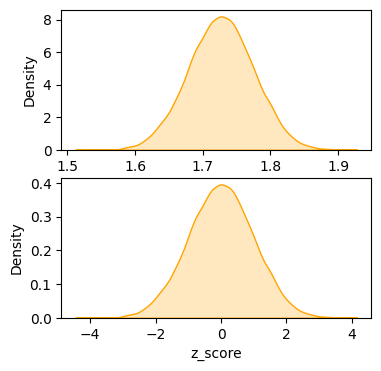

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(4, 4))

sns.kdeplot(humans['Height(m)'], fill=True, ax=ax[0], color='orange')
sns.kdeplot(humans['z_score']    , fill=True, ax=ax[1], color='orange')

plt.show()

### 2. IQR Method

By convention, a data point may be considered to be an *outlier* if it lies outside of the **Inter-quartile range (IQR)** by more than 1.5 times the IQR. i.e.:

$$
x < Q_1 - 1.5 \times \text{IQR}\\
x > Q_3 + 1.5 \times \text{IQR}
$$

![Box and Whiskers Plot](../assets/stats/box-and-whiskers_plot.png)

### Box-and-whiskers Plot

A [**boxplot**](https://www.data-to-viz.com/#boxplot) gives a nice summary of one or several numeric variables. The line that divides the box into 2 parts represents the median of the data. The end of the box shows the upper and lower quartiles. The extreme lines show the highest and lowest value excluding outliers.

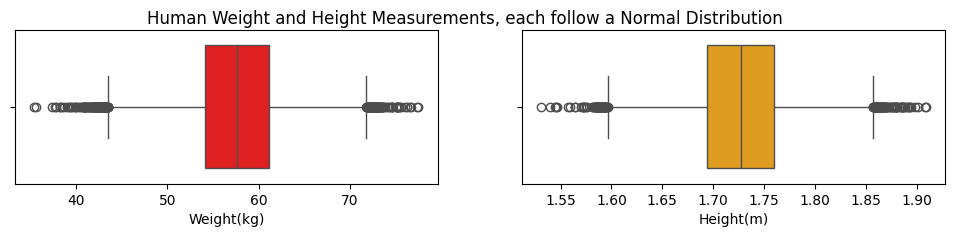

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 2))

fig.suptitle("Human Weight and Height Measurements, each follow a Normal Distribution")
sns.boxplot(humans, x="Weight(kg)", color="red", ax=ax[0]);
sns.boxplot(humans, x="Height(m)", color="orange", ax=ax[1]);

In [14]:
q1 = humans['Height(m)'].quantile(0.25)
q3 = humans['Height(m)'].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5*iqr
uppwer_whisker = q3 + 1.5*iqr

How many outliers do we have? (considering the IQR method?)

In [15]:
cond1 = humans['Height(m)'] > uppwer_whisker
cond2 = humans['Height(m)'] < lower_whisker
num_iqr_outliers = humans[cond1 | cond2].shape[0]

In [16]:
print("Z-score outliers:", num_z_score_outliers)
print("    IQR outliers:", num_iqr_outliers)

Z-score outliers: 51
    IQR outliers: 167


### Comparing IQR & Z-score methods

We notice that the IQR-method is more conservative; i.e., **flags more outliers** compared to the z-score method.

![](../assets/stats/boxplot_vs_normal.png)